FIRST 5 ROWS:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target

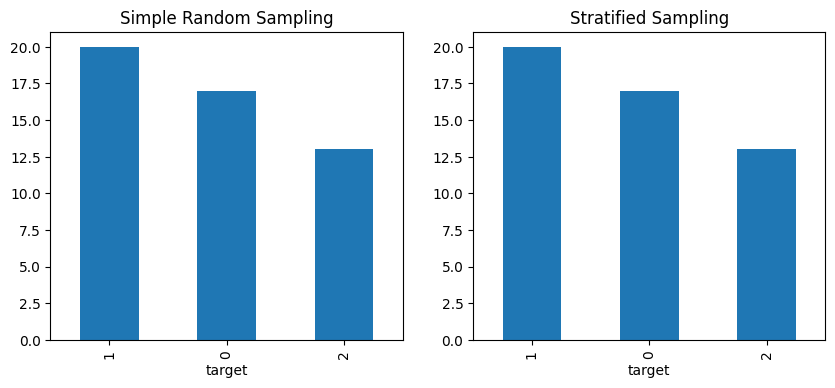


Imbalanced class distribution:
target
1    71
0    59
2    10
Name: count, dtype: int64

Balanced class distribution after SMOTE:
target
0    71
1    71
2    71
Name: count, dtype: int64

--- Random Forest Performance ---
Imbalanced Precision: 0.9565217391304347
Imbalanced Recall: 0.75
Imbalanced F1: 0.7767441860465115

Balanced Precision: 0.9814814814814815
Balanced Recall: 0.9855072463768115
Balanced F1: 0.9830687830687831

Heuristic labels added:
   alcohol  alcohol_label
0    14.23              1
1    13.20              0
2    13.16              0
3    14.37              1
4    13.24              0


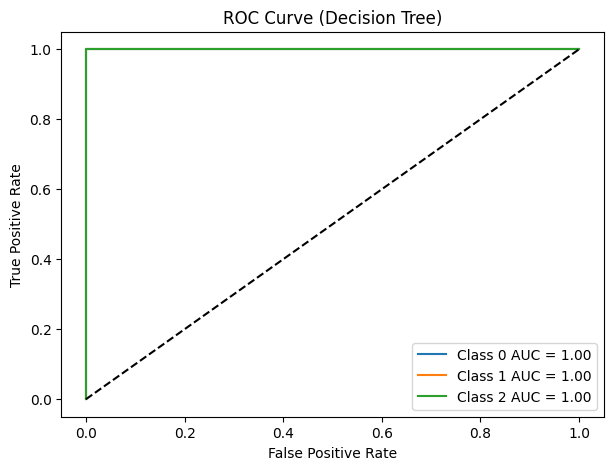


AUC Scores: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}
Original Accuracy: 0.9814814814814815
Augmented Accuracy: 0.9814814814814815


In [6]:
# ============================================================
# 1. LOAD AND EXPLORE THE WINE DATASET
# ============================================================

from sklearn.datasets import load_wine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression

# Load dataset
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target

print("FIRST 5 ROWS:")
print(df.head())

print("\nNumber of samples:", df.shape[0])
print("Number of features:", df.shape[1] - 1)
print("Number of classes:", df["target"].nunique())
print("\nClass distribution:")
print(df["target"].value_counts())


# ============================================================
# 2. SIMPLE RANDOM SAMPLING & STRATIFIED SAMPLING
# ============================================================

# Simple Random Sampling (50 samples)
simple_random_sample = df.sample(n=50, random_state=42)

# Stratified Sampling (50 samples)
split = StratifiedShuffleSplit(n_splits=1, test_size=50, random_state=42)
for _, strat_index in split.split(df, df["target"]):
    stratified_sample = df.iloc[strat_index]

# Plot class distributions
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
simple_random_sample["target"].value_counts().plot(kind="bar", title="Simple Random Sampling")

plt.subplot(1,2,2)
stratified_sample["target"].value_counts().plot(kind="bar", title="Stratified Sampling")

plt.show()


# ============================================================
# 3. HANDLE CLASS IMBALANCE + SMOTE + RANDOM FOREST
# ============================================================

# Create imbalanced dataset (reduce class 2)
imbalanced_df = df.copy()
imbalanced_df = pd.concat([
    imbalanced_df[imbalanced_df["target"] == 0],
    imbalanced_df[imbalanced_df["target"] == 1],
    imbalanced_df[imbalanced_df["target"] == 2].sample(10, random_state=42)
])

print("\nImbalanced class distribution:")
print(imbalanced_df["target"].value_counts())

# Apply SMOTE
X = imbalanced_df.drop("target", axis=1)
y = imbalanced_df["target"]

sm = SMOTE(random_state=42)
X_bal, y_bal = sm.fit_resample(X, y)

print("\nBalanced class distribution after SMOTE:")
print(pd.Series(y_bal).value_counts())

# Train Random Forest on imbalanced data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
rf_imbalanced = RandomForestClassifier().fit(X_train, y_train)
y_pred_imbalanced = rf_imbalanced.predict(X_test)

# Train Random Forest on balanced data
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_bal, y_bal, test_size=0.3, random_state=42)
rf_balanced = RandomForestClassifier().fit(X_train2, y_train2)
y_pred_balanced = rf_balanced.predict(X_test2)

# Compare performance
print("\n--- Random Forest Performance ---")
print("Imbalanced Precision:", precision_score(y_test, y_pred_imbalanced, average='macro'))
print("Imbalanced Recall:", recall_score(y_test, y_pred_imbalanced, average='macro'))
print("Imbalanced F1:", f1_score(y_test, y_pred_imbalanced, average='macro'))

print("\nBalanced Precision:", precision_score(y_test2, y_pred_balanced, average='macro'))
print("Balanced Recall:", recall_score(y_test2, y_pred_balanced, average='macro'))
print("Balanced F1:", f1_score(y_test2, y_pred_balanced, average='macro'))


# ============================================================
# 4. LABELING DATA USING HEURISTICS
# ============================================================

# Simple rule: If alcohol > 13.5 → label = 1 else 0
df["alcohol_label"] = (df["alcohol"] > 13.5).astype(int)

print("\nHeuristic labels added:")
print(df[["alcohol", "alcohol_label"]].head())


# ============================================================
# 5. DECISION TREE + ROC CURVE + AUC
# ============================================================

X = df.drop("target", axis=1)
y = df["target"]

dt = DecisionTreeClassifier().fit(X, y)

# Binarize labels for ROC
y_bin = label_binarize(y, classes=[0,1,2])
y_score = dt.predict_proba(X)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curve
plt.figure(figsize=(7,5))
for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} AUC = {roc_auc[i]:.2f}")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Decision Tree)")
plt.legend()
plt.show()

print("\nAUC Scores:", roc_auc)


# ============================================================
# 6. DATA AUGMENTATION + LOGISTIC REGRESSION
# ============================================================

# DATA AUGMENTATION + SCALING
df_aug = df.copy()
noise = np.random.normal(0, 0.1, df_aug[wine.feature_names].shape)
df_aug[wine.feature_names] = df_aug[wine.feature_names] + noise

# ORIGINAL DATA
X = df[wine.feature_names]
y = df["target"]

# AUGMENTED DATA
X_aug = df_aug[wine.feature_names]
y_aug = df_aug["target"]

# SCALE BOTH DATASETS
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X = scaler.fit_transform(X)
X_aug = scaler.fit_transform(X_aug)

# TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_aug, y_aug, test_size=0.3, random_state=42)

# LOGISTIC REGRESSION
lr_original = LogisticRegression(max_iter=3000).fit(X_train, y_train)
lr_aug = LogisticRegression(max_iter=3000).fit(X_train2, y_train2)

print("Original Accuracy:", lr_original.score(X_test, y_test))
print("Augmented Accuracy:", lr_aug.score(X_test2, y_test2))